### Import Required Libraries

The required libraries are imported for collecting Google Trends data, processing the data, and creating visualizations.

In [2]:
import pandas as pd
from pytrends.request import TrendReq
import matplotlib.pyplot as plt
import seaborn as sns

### Connecting to Google Trends

A connection is created with Google Trends using PyTrends to retrieve search interest data.

In [3]:
trending_topics = TrendReq(
    hl='en-US',
    tz=360
)

### Collecting Search Trend Data

The search interest data for selected keywords is collected over the last year.  
The retrieved data will be saved locally to avoid repeated requests to Google Trends.

In [4]:
kw_list = [
    "Cloud Computing",
    "Artificial Intelligence",
    "Data Science"
]

trending_topics.build_payload(
    kw_list,
    cat=0,
    timeframe="today 12-m"
)

comparison = trending_topics.interest_over_time()

comparison.drop(columns=["isPartial"], inplace=True)

comparison.head()

,Cloud Computing,Artificial Intelligence,Data Science
date,,,
2025-07-27,8,33,30
2025-08-03,9,43,41
2025-08-10,11,56,50
2025-08-17,12,54,51
2025-08-24,11,43,45


### Saving Google Trends Data

The collected Google Trends data is saved as a CSV file so that further analysis can be performed without sending additional requests to Google.

In [6]:
comparison.to_csv("google_trends_data.csv")

### Loading Stored Data

The saved dataset is loaded for analysis and visualization.

In [7]:
data = pd.read_csv(
    "google_trends_data.csv",
    index_col=0,
    parse_dates=True
)

data.head()

,Cloud Computing,Artificial Intelligence,Data Science
date,,,
2025-07-27,8,33,30
2025-08-03,9,43,41
2025-08-10,11,56,50
2025-08-17,12,54,51
2025-08-24,11,43,45


### Comparing Search Trends

The search popularity of different keywords is compared over time to identify changes in user interest.

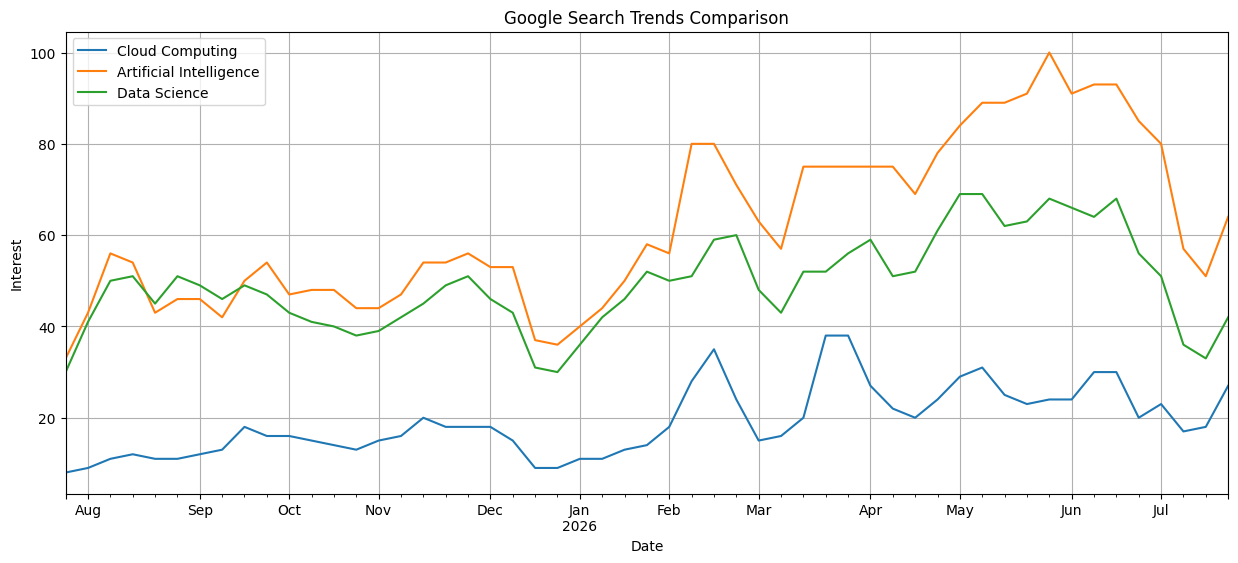

In [8]:
data.plot(figsize=(15,6))

plt.title("Google Search Trends Comparison")
plt.xlabel("Date")
plt.ylabel("Interest")

plt.grid(True)
plt.show()

### Average Search Interest

The average search interest for each keyword is calculated to determine which topic has the highest overall popularity.

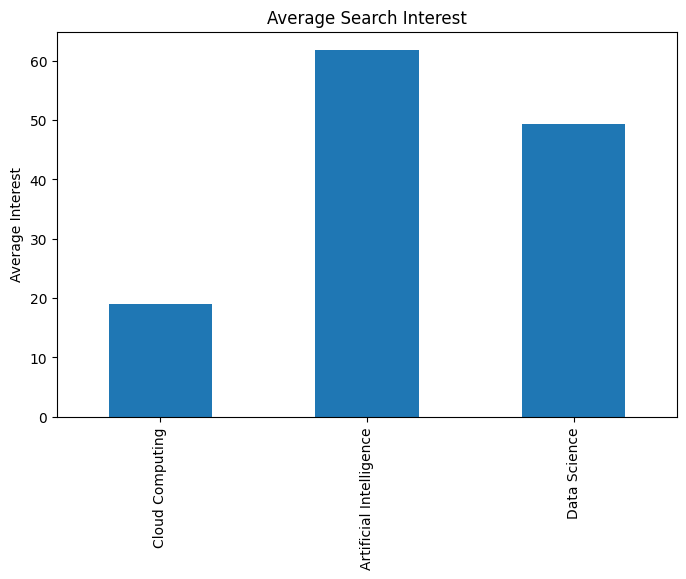

In [9]:
average = data.mean()

average.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Search Interest")
plt.ylabel("Average Interest")

plt.show()

### Monthly Search Trend Analysis

The data is grouped by month to analyze seasonal patterns and monthly changes in search behavior.

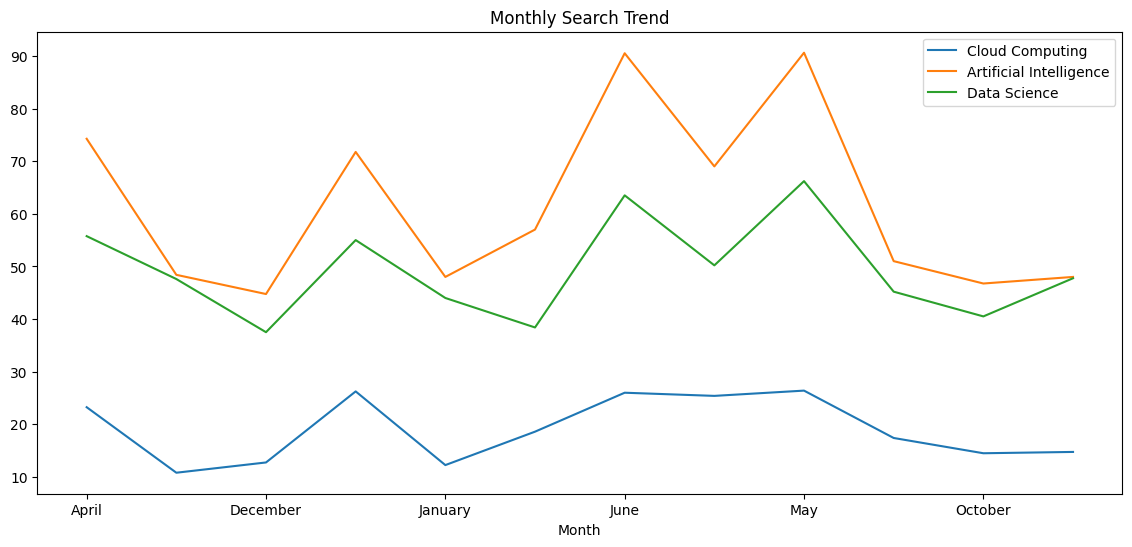

In [10]:
monthly = data.copy()

monthly["Month"] = monthly.index.month_name()

monthly_avg = monthly.groupby("Month").mean()

monthly_avg.plot(figsize=(14,6))

plt.title("Monthly Search Trend")

plt.show()

### Correlation Analysis

Correlation analysis is performed to understand the relationship between different search keywords.

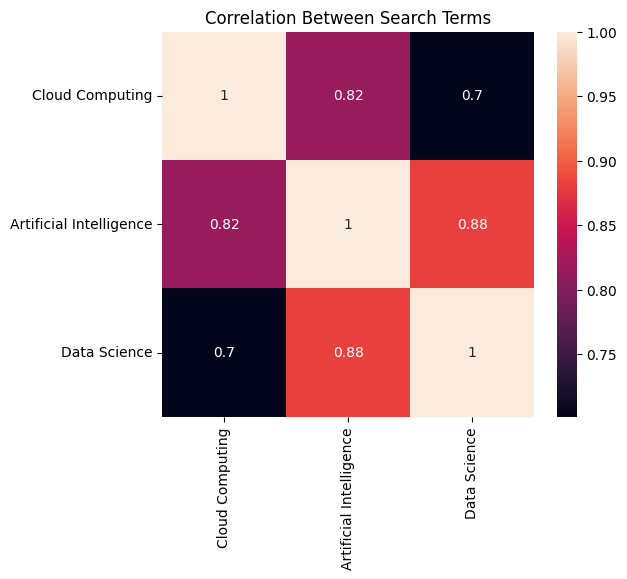

In [11]:
plt.figure(figsize=(6,5))

sns.heatmap(
    data.corr(),
    annot=True
)

plt.title("Correlation Between Search Terms")

plt.show()

### Finding Peak Search Days

The dates with the highest search interest are identified for each keyword.

In [12]:
for keyword in kw_list:

    max_day = data[keyword].idxmax()
    max_value = data[keyword].max()

    print(keyword)
    print("Highest Search Date:", max_day)
    print("Interest:", max_value)
    print("----------------")

Cloud Computing
Highest Search Date: 2026-03-22 00:00:00
Interest: 38
----------------
Artificial Intelligence
Highest Search Date: 2026-05-31 00:00:00
Interest: 100
----------------
Data Science
Highest Search Date: 2026-05-03 00:00:00
Interest: 69
----------------


### 7-Day Moving Average

A 7-day moving average is applied to smooth daily fluctuations and highlight the overall search trend.

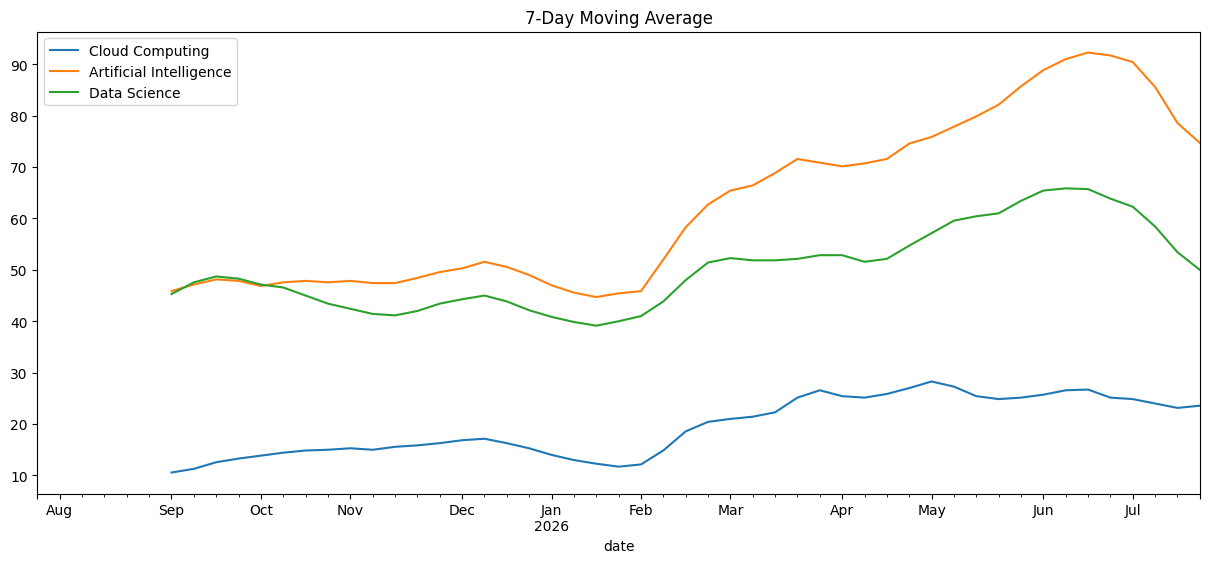

In [13]:
rolling = data.rolling(window=7).mean()

rolling.plot(figsize=(15,6))

plt.title("7-Day Moving Average")

plt.show()

### Keyword Suggestions

Google Trends suggestions are used to discover related keywords and topics.

In [14]:
suggestions = trending_topics.suggestions(
    keyword="Cloud Computing"
)

suggestions_df = pd.DataFrame(suggestions)

suggestions_df.drop(
    columns=["mid"],
    inplace=True
)

suggestions_df

,title,type
0,Cloud computing,Organization type
1,Cloud computing architecture,Topic
2,Serverless computing,Topic
3,Cloud computing security,Topic
4,Private cloud computing infrastructure,Topic
